# EXP-007 — Hierarchical 2/4/6-mer LR + fixed GC201 bins

**Статус:** подготовлен, но ни одна code cell не выполнена.

EXP-006 показал сильную, но немонотонную связь GC201 с target.
Один линейный коэффициент ухудшил validation AP. Здесь меняется
только представление GC201: линейный столбец заменяется фиксированными
категориальными диапазонами.

Не используйте **Run All**. Выполняйте ячейки сверху вниз.


## Карта эксперимента

1. Воспроизвести тот же split и точные `6-mer × GC201` counts.
2. Проверить train-only enrichment общим графиком и отдельно по folds.
3. Собрать exact likelihood с восемью GC-контрастами.
4. Остановиться перед 39 train-CV fits.
5. Выбрать `C` и сравнить каждый fold с EXP-005.
6. Не открывать validation, если хотя бы один fold проигран.
7. После фиксации модели оценить EXP-007 против EXP-005, EXP-006 и
   champion EXP-003; сохранить графики и отчёт.


In [1]:
from pathlib import Path
import json
import platform
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = next(
    candidate for candidate in (CURRENT_DIR, *CURRENT_DIR.parents)
    if (candidate / "README.md").is_file()
    and (candidate / "src/ml_project").is_dir()
)
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from ml_project.epic_baseline import load_baseline_sequences
from ml_project.epic_data import ensure_prepared_split
from ml_project.epic_experiment import (
    ExperimentSpec,
    build_run_record,
    save_run_record,
)
from ml_project.epic_gc_binned_logistic import (
    GC_BIN_LABELS,
    GCBinnedLogisticConfig,
    aggregate_binned_gc_binary_likelihood,
    cross_validate_binned_gc_logistic,
    evaluate_binned_gc_logistic,
    fit_binned_gc_logistic,
    gc_bin_enrichment_table,
    gc_bin_feature_table,
    selected_cv_bin_coefficients,
)
from ml_project.epic_gc_logistic import (
    gc_count_diagnostics,
    kmer_counts_from_gc_counts,
    split_kmer_gc_counts,
)
from ml_project.epic_kmer import (
    KmerLookupConfig,
    evaluate_kmer_lookup,
    fit_kmer_lookup,
)
from ml_project.epic_kmer_logistic import (
    hierarchical_kmer_design,
    make_balanced_contig_folds,
    select_regularization,
    summarise_cv,
)

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
})
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 100)

display(pd.Series({
    "python": platform.python_version(),
    "executable": sys.executable,
    "project_root": str(PROJECT_ROOT),
    "notebook_state": "prepared / unexecuted",
}, name="value").to_frame())


,value
python,3.12.14
executable,C:\ML_Progs\Runtimes\Miniforge3\envs\epic-eda\...
project_root,D:\Projects\EPIC\EPIC
notebook_state,prepared / unexecuted


## 1. Зафиксированный конфиг

`GC201 = (G+C)/(A+C+G+T)` в inclusive-окне `[-100,+100]`.
`N` и края contig не входят в знаменатель. Линейного GC-признака
здесь нет: используется ровно одна фиксированная категория.


In [2]:
RUN_NAME = "run_001"
EXPERIMENT_ID = "EXP-007"
NOTEBOOK_PATH = PROJECT_ROOT / "notebooks/experiments/EXP-007_gc201_bins_logistic.ipynb"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts/experiments/EXP-007" / RUN_NAME
PLOT_DIR = ARTIFACT_DIR / "plots"

CONFIG = GCBinnedLogisticConfig()
LOOKUP_CONFIG = KmerLookupConfig(
    ks=CONFIG.ks,
    smoothing="one_expected_positive",
)
SPEC = ExperimentSpec(
    experiment_id=EXPERIMENT_ID,
    title="Hierarchical 2/4/6-mer Logistic Regression + fixed GC201 bins",
    hypothesis=(
        "The GC201 signal is transferable when represented as a fixed "
        "non-monotonic categorical effect instead of one linear coefficient"
    ),
    changed_variable=(
        "EXP-005 hierarchical features + fixed reference-coded GC201 bins"
    ),
    success_criterion=(
        "Before validation: AP win over EXP-005 on all 3 identical CV folds; "
        "champion gate: validation AP gain vs EXP-003 >= 1%, Spearman not lower, "
        "AP wins on at least 2/3 validation contigs"
    ),
    seed=CONFIG.seed,
)
assert not (ARTIFACT_DIR / "metadata.json").exists(), (
    f"Run already exists: {ARTIFACT_DIR}. Use another run name; do not overwrite."
)
display(pd.Series(CONFIG.to_dict(), name="value").to_frame())
display(gc_bin_feature_table(CONFIG))


,value
ks,"[2, 4, 6]"
window_start,-100
window_end,100
C_grid,"[0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03, 0.1..."
penalty,l2
solver,lbfgs
max_iter,2000
tol,0.0
threads,2
seed,42


,bin_code,bin_label,feature_index_within_gc,feature_name,feature_group
0,0,<0.30,0,gc201_bin=<0.30,GC201 bin
1,1,"[0.30,0.35)",1,"gc201_bin=[0.30,0.35)",GC201 bin
2,3,"[0.40,0.45)",2,"gc201_bin=[0.40,0.45)",GC201 bin
3,4,"[0.45,0.50)",3,"gc201_bin=[0.45,0.50)",GC201 bin
4,5,"[0.50,0.55)",4,"gc201_bin=[0.50,0.55)",GC201 bin
5,6,"[0.55,0.60)",5,"gc201_bin=[0.55,0.60)",GC201 bin
6,7,>=0.60,6,gc201_bin=>=0.60,GC201 bin
7,8,missing,7,gc201_bin=missing,GC201 bin


## 2. Неизменный split

Используется `contig_holdout_v1`. Все решения до validation-gate
принимаются только по девяти train-contig.


In [3]:
split = ensure_prepared_split(PROJECT_ROOT)
display(split.summary)
display(split.contig_assignment.sort_values(["split", "contig"]))
assert split.config.split_version == "contig_holdout_v1"
assert split.config.seed == CONFIG.seed


,split,contigs,intervals_both_strands,whitelist_bp,position_strand_count,percent_of_all_positions,positive_positions,negative_positions,positive_percent
0,train,9,168998,114032080,228064160,59.316784,170443.0,227893717.0,0.074735
1,validation,3,60386,41903743,83807486,21.797334,56205.0,83751281.0,0.067064
2,test,3,54846,36306695,72613390,18.885882,NaN,NaN,NaN


,contig,split,source_split
12,NC_064037.1,test,test
13,NC_064044.1,test,test
14,NC_064046.1,test,test
1,NC_064035.1,train,train
2,NC_064036.1,train,train
3,NC_064038.1,train,train
4,NC_064039.1,train,train
5,NC_064040.1,train,train
8,NC_064043.1,train,train
9,NC_064045.1,train,train


In [4]:
sequences, fasta_alphabet = load_baseline_sequences(split)
display(pd.Series({
    "contigs_loaded": len(sequences),
    "total_fasta_bp": sum(map(len, sequences.values())),
    "alphabet": fasta_alphabet,
}, name="value").to_frame())


,value
contigs_loaded,47
total_fasta_bp,269418438
alphabet,"{'A': 54173800, 'C': 39020211, 'G': 38944862, ..."


## 3. Точный расчёт без sampling

Prefix sums дают `gc_count` и `valid_count` за `O(1)` для каждой
позиции. Затем данные сворачиваются по
`contig × strand × 6-mer × gc_count × valid_count × target`.
Multiplicity передаётся через `sample_weight`.


In [5]:
started = time.monotonic()
train_gc_counts = split_kmer_gc_counts(
    split,
    sequences,
    "train",
    config=CONFIG,
)
train_count_seconds = time.monotonic() - started
train_gc_diagnostics = gc_count_diagnostics(train_gc_counts)
display(train_gc_diagnostics)
print(f"Full train counted in {train_count_seconds:.2f} s")


,split,aggregate_rows,positions,positives,unique_gc_fractions,zero_valid_positions,zero_valid_fraction,totals_memory_mib,positives_memory_mib
0,train,6070347,228064160,170443,7502,0,0.0,729.431013,24.382193


Full train counted in 32.80 s


In [6]:
expected_train = int(split.summary.loc[
    split.summary["split"] == "train", "position_strand_count"
].iloc[0])
expected_positive = int(split.summary.loc[
    split.summary["split"] == "train", "positive_positions"
].iloc[0])
assert int(train_gc_counts.totals["total_positions"].sum()) == expected_train
assert len(train_gc_counts.positives) == expected_positive
assert (train_gc_counts.totals["gc_count"] <= train_gc_counts.totals["valid_count"]).all()
display(train_gc_counts.totals.head(10))
display(train_gc_counts.positives.head(10))


,contig,strand,kmer_6_code,gc_count,valid_count,total_positions
0,NC_064035.1,+,0,30,201,1
1,NC_064035.1,+,0,32,201,3
2,NC_064035.1,+,0,34,201,2
3,NC_064035.1,+,0,35,201,2
4,NC_064035.1,+,0,36,201,2
5,NC_064035.1,+,0,37,201,4
6,NC_064035.1,+,0,38,201,4
7,NC_064035.1,+,0,39,201,10
8,NC_064035.1,+,0,40,201,26
9,NC_064035.1,+,0,41,201,12


,template_index,contig,coordinate_0based,strand,count,kmer_6_code,gc_count,valid_count,gc_fraction
0,17031126,NC_064035.1,886447,+,2,44,70,201,0.348259
1,17032244,NC_064035.1,887565,+,1,1012,88,201,0.437811
2,17034634,NC_064035.1,890311,+,9,916,94,201,0.467662
3,17034774,NC_064035.1,890451,+,1,3456,77,201,0.383085
4,17036374,NC_064035.1,893355,+,1,423,72,201,0.358209
5,17036381,NC_064035.1,893362,+,2,538,72,201,0.358209
6,17051902,NC_064035.1,913273,+,1,3359,83,201,0.412935
7,17055629,NC_064035.1,917304,+,29,3476,82,201,0.407960
8,17055653,NC_064035.1,917328,+,1,320,81,201,0.402985
9,17055669,NC_064035.1,917344,+,1,4030,79,201,0.393035


In [7]:
train_kmer_counts = kmer_counts_from_gc_counts(train_gc_counts, ks=CONFIG.ks)
fold_assignment = make_balanced_contig_folds(
    train_kmer_counts,
    k=CONFIG.max_k,
    n_splits=CONFIG.cv_folds,
)
display(fold_assignment)
assert not fold_assignment["contig"].duplicated().any()
assert set(fold_assignment["fold"]) == set(range(CONFIG.cv_folds))


,contig,positions,positives,fold,prevalence
0,NC_064035.1,33456756,30987,0,0.000926
1,NC_064043.1,24039838,19558,0,0.000814
2,NC_064048.1,17926958,10888,0,0.000607
3,NC_064036.1,31610378,26323,1,0.000833
4,NC_064038.1,25217952,14793,1,0.000587
5,NC_064045.1,20367114,15184,1,0.000746
6,NC_064039.1,27686596,21975,2,0.000794
7,NC_064040.1,26051020,19067,2,0.000732
8,NC_064047.1,21707548,11668,2,0.000538


## 4. Train-only устойчивость GC-bins

Общая кривая может скрыть различия между contig. Поэтому enrichment
строится как для всего train, так и отдельно для каждой группы,
которая будет validation-fold в CV. Эти графики не используют
внешнюю validation.


,gc_bin_code,gc_bin,positions,positives,positive_rate,enrichment
0,0,<0.30,13595704,1097,0.000081,0.107965
1,1,"[0.30,0.35)",40997704,9041,0.000221,0.295077
2,2,"[0.35,0.40)",62768838,35534,0.000566,0.757492
3,3,"[0.40,0.45)",56256060,62203,0.001106,1.479517
4,4,"[0.45,0.50)",34042900,45084,0.001324,1.772041
5,5,"[0.50,0.55)",14123306,14104,0.000999,1.336238
6,6,"[0.55,0.60)",4902654,2600,0.000530,0.709610
7,7,>=0.60,1376994,780,0.000566,0.757950
8,8,missing,0,0,NaN,NaN


,gc_bin_code,gc_bin,positions,positives,positive_rate,enrichment,fold,contigs
0,0,<0.30,4402752,403,0.000092,0.112379,0,"NC_064035.1,NC_064043.1,NC_064048.1"
1,1,"[0.30,0.35)",13661582,3334,0.000244,0.299619,0,"NC_064035.1,NC_064043.1,NC_064048.1"
2,2,"[0.35,0.40)",21139650,12371,0.000585,0.718476,0,"NC_064035.1,NC_064043.1,NC_064048.1"
3,3,"[0.40,0.45)",18753162,22546,0.001202,1.476047,0,"NC_064035.1,NC_064043.1,NC_064048.1"
4,4,"[0.45,0.50)",11229792,16497,0.001469,1.803593,0,"NC_064035.1,NC_064043.1,NC_064048.1"
5,5,"[0.50,0.55)",4459730,5253,0.001178,1.446119,0,"NC_064035.1,NC_064043.1,NC_064048.1"
6,6,"[0.55,0.60)",1402468,832,0.000593,0.728342,0,"NC_064035.1,NC_064043.1,NC_064048.1"
7,7,>=0.60,374416,197,0.000526,0.645977,0,"NC_064035.1,NC_064043.1,NC_064048.1"
8,8,missing,0,0,NaN,NaN,0,"NC_064035.1,NC_064043.1,NC_064048.1"
9,0,<0.30,4662206,345,0.000074,0.101464,1,"NC_064036.1,NC_064038.1,NC_064045.1"


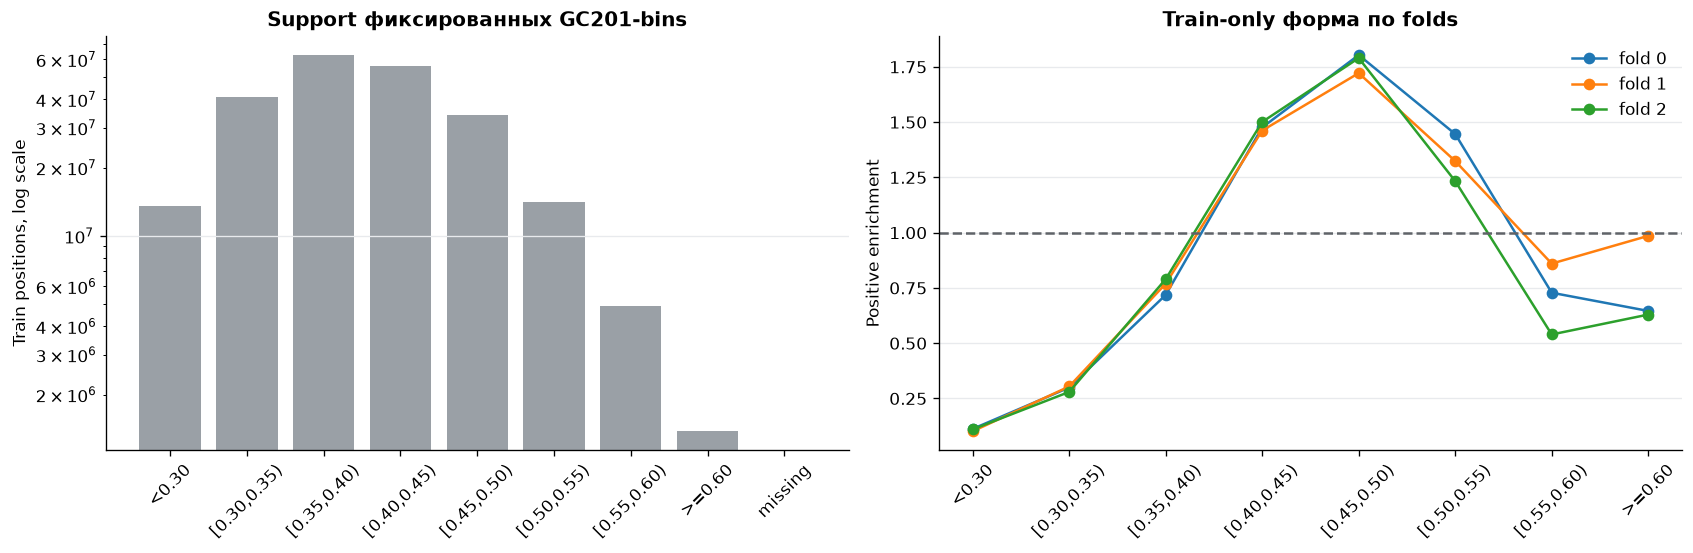

In [8]:
train_bin_enrichment = gc_bin_enrichment_table(train_gc_counts)
fold_bin_frames = []
for fold in sorted(fold_assignment["fold"].unique()):
    contigs = fold_assignment.loc[
        fold_assignment["fold"] == fold, "contig"
    ].tolist()
    table = gc_bin_enrichment_table(train_gc_counts, contigs=contigs)
    table["fold"] = int(fold)
    table["contigs"] = ",".join(contigs)
    fold_bin_frames.append(table)
fold_bin_enrichment = pd.concat(fold_bin_frames, ignore_index=True)
display(train_bin_enrichment)
display(fold_bin_enrichment)

fig_train_bins, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
axes[0].bar(
    train_bin_enrichment["gc_bin"],
    train_bin_enrichment["positions"],
    color="#9AA0A6",
)
axes[0].set_yscale("log")
axes[0].set_ylabel("Train positions, log scale")
axes[0].set_title("Support фиксированных GC201-bins")
for fold, frame in fold_bin_enrichment.groupby("fold"):
    axes[1].plot(
        frame["gc_bin"],
        frame["enrichment"],
        marker="o",
        label=f"fold {fold}",
    )
axes[1].axhline(1.0, color="#5F6368", linestyle="--")
axes[1].set_ylabel("Positive enrichment")
axes[1].set_title("Train-only форма по folds")
axes[1].legend(frameon=False)
for ax in axes:
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", color="#E8EAED")
plt.show()


In [9]:
design = hierarchical_kmer_design(CONFIG)
train_aggregate_preview = aggregate_binned_gc_binary_likelihood(
    train_gc_counts,
    design,
    config=CONFIG,
)
aggregate_report = pd.Series({
    "hierarchical_one_hot_columns": design.matrix.shape[1],
    "gc_bin_contrast_columns": len(gc_bin_feature_table(CONFIG)),
    "candidate_columns": train_aggregate_preview.matrix.shape[1],
    "aggregate_binary_rows": len(train_aggregate_preview.rows),
    "represented_positions": int(train_aggregate_preview.rows["population_count"].sum()),
    "matrix_memory_mib": (
        train_aggregate_preview.matrix.data.nbytes
        + train_aggregate_preview.matrix.indices.nbytes
        + train_aggregate_preview.matrix.indptr.nbytes
    ) / 2**20,
}, name="value").to_frame()
display(aggregate_report)
assert train_aggregate_preview.matrix.shape[1] == 4379
assert int(train_aggregate_preview.rows["population_count"].sum()) == expected_train
del train_aggregate_preview


,value
hierarchical_one_hot_columns,4.371000e+03
gc_bin_contrast_columns,8.000000e+00
candidate_columns,4.379000e+03
aggregate_binary_rows,5.341590e+05
represented_positions,2.280642e+08
matrix_memory_mib,2.575160e+01


In [10]:
cv_plan = pd.Series({
    "folds": CONFIG.cv_folds,
    "C_values": len(CONFIG.C_grid),
    "planned_fits": CONFIG.cv_folds * len(CONFIG.C_grid),
    "C_grid": CONFIG.C_grid,
    "max_iter": CONFIG.max_iter,
    "tol": CONFIG.tol,
}, name="value").to_frame()
display(cv_plan)


,value
folds,3
C_values,13
planned_fits,39
C_grid,"(0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03, 0.1..."
max_iter,2000
tol,0.0


# STOP 1 — дальше начинается обучение

До этой точки модели не обучались. Проверьте exact counts, support
хвостовых bins, график enrichment по трём folds и `candidate_columns=4379`.
Следующая ячейка выполнит 39 fits и будет печатать прогресс после
каждого завершённого fit.


In [11]:
started = time.monotonic()
cv_results = cross_validate_binned_gc_logistic(
    train_gc_counts,
    fold_assignment,
    config=CONFIG,
    verbose=True,
)
cv_seconds = time.monotonic() - started
print(f"Train-only CV finished in {cv_seconds:.2f} s")
display(cv_results.head())


C:\ML_Progs\Runtimes\Miniforge3\envs\epic-eda\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


[01/39] fold=0 C=0.0001 AP=0.002576216 iter=222 time=4.27s converged=True


C:\ML_Progs\Runtimes\Miniforge3\envs\epic-eda\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


[02/39] fold=0 C=0.0003 AP=0.002579426 iter=329 time=6.23s converged=True


C:\ML_Progs\Runtimes\Miniforge3\envs\epic-eda\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


...

C:\ML_Progs\Runtimes\Miniforge3\envs\epic-eda\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


[38/39] fold=2 C=30 AP=0.002209242 iter=2000 time=37.08s converged=False


C:\ML_Progs\Runtimes\Miniforge3\envs\epic-eda\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


[39/39] fold=2 C=100 AP=0.002209253 iter=2000 time=36.95s converged=False
Train-only CV finished in 951.16 s


,C,fold,validation_contigs,segment,variant,average_precision,epic_spearman,population_log_loss,balanced_log_loss,positions,positives,prevalence,iterations,converged,fit_seconds,aggregate_rows,warnings,gc_bin_coefficient_0,gc_bin_coefficient_1,gc_bin_coefficient_2,gc_bin_coefficient_3,gc_bin_coefficient_4,gc_bin_coefficient_5,gc_bin_coefficient_6,gc_bin_coefficient_7,gc_bin_coefficient_8
0,0.0001,0,"NC_064035.1,NC_064043.1,NC_064048.1","NC_064035.1,NC_064043.1,NC_064048.1",EXP-007 hierarchical LR + binned GC201,0.002576,0.089599,0.594918,0.592350,75423552,61433,0.000815,222,True,4.265,494092,,-1.886557,-0.945156,0.0,0.625936,0.800578,0.521279,-0.032485,0.192720,0.0
1,0.0001,1,"NC_064036.1,NC_064038.1,NC_064045.1","NC_064036.1,NC_064038.1,NC_064045.1",EXP-007 hierarchical LR + binned GC201,0.002161,0.083983,0.594130,0.598450,77195444,56300,0.000729,219,True,4.172,494517,,-1.795516,-0.913352,0.0,0.664453,0.855700,0.593574,-0.137744,-0.035021,0.0
2,0.0001,2,"NC_064039.1,NC_064040.1,NC_064047.1","NC_064039.1,NC_064040.1,NC_064047.1",EXP-007 hierarchical LR + binned GC201,0.002218,0.088435,0.593751,0.590859,75445164,52710,0.000699,227,True,4.375,498235,,-1.828036,-0.867130,0.0,0.666139,0.847785,0.637450,0.129251,0.243663,0.0
3,0.0003,0,"NC_064035.1,NC_064043.1,NC_064048.1","NC_064035.1,NC_064043.1,NC_064048.1",EXP-007 hierarchical LR + binned GC201,0.002579,0.090699,0.593043,0.592393,75423552,61433,0.000815,329,True,6.234,494092,,-1.909571,-0.945612,0.0,0.624645,0.796924,0.515519,-0.042786,0.169811,0.0
4,0.0003,1,"NC_064036.1,NC_064038.1,NC_064045.1","NC_064036.1,NC_064038.1,NC_064045.1",EXP-007 hierarchical LR + binned GC201,0.002167,0.085675,0.592258,0.598547,77195444,56300,0.000729,342,True,6.313,494517,,-1.816743,-0.914367,0.0,0.662802,0.851369,0.588243,-0.151040,-0.053044,0.0


In [12]:
cv_summary = summarise_cv(cv_results)
nonconverged = cv_summary.loc[~cv_summary["all_folds_converged"].astype(bool)]
display(cv_summary.style.format({
    "mean_average_precision": "{:.9f}",
    "std_average_precision": "{:.9f}",
    "mean_epic_spearman": "{:.6f}",
    "std_epic_spearman": "{:.6f}",
    "mean_balanced_log_loss": "{:.6f}",
    "total_fit_seconds": "{:.2f}",
}))
if len(nonconverged):
    display(Markdown(
        "**Несошедшиеся C исключаются из выбора:** "
        + ", ".join(map(str, nonconverged["C"]))
    ))
assert cv_summary["all_folds_converged"].any(), "Ни один C не сошёлся"


,C,mean_average_precision,std_average_precision,mean_epic_spearman,std_epic_spearman,mean_balanced_log_loss,all_folds_converged,max_iterations,total_fit_seconds
0,0.000100,0.002318267,0.000225176,0.087339,0.002964,0.593887,True,227,12.81
1,0.000300,0.002323630,0.000223358,0.088777,0.002712,0.593948,True,342,19.16
2,0.001000,0.002316194,0.000220061,0.089455,0.002395,0.594988,True,578,30.88
3,0.003000,0.002310579,0.000218550,0.089638,0.002231,0.595835,True,788,43.00
4,0.010000,0.002307495,0.000217796,0.089696,0.002162,0.596324,True,1097,60.64
5,0.030000,0.002306532,0.000217580,0.089709,0.002136,0.596517,True,1656,77.05
6,0.100000,0.002306215,0.000217485,0.089714,0.002128,0.596615,False,2000,93.59
7,0.300000,0.002306114,0.000217457,0.089716,0.002128,0.596667,True,1809,71.97
8,1.000000,0.002306083,0.000217467,0.089716,0.002126,0.596711,False,2000,85.39
9,3.000000,0.002306072,0.000217469,0.089716,0.002126,0.596743,False,2000,89.22


**Несошедшиеся C исключаются из выбора:** 0.1, 1.0, 3.0, 10.0, 30.0, 100.0

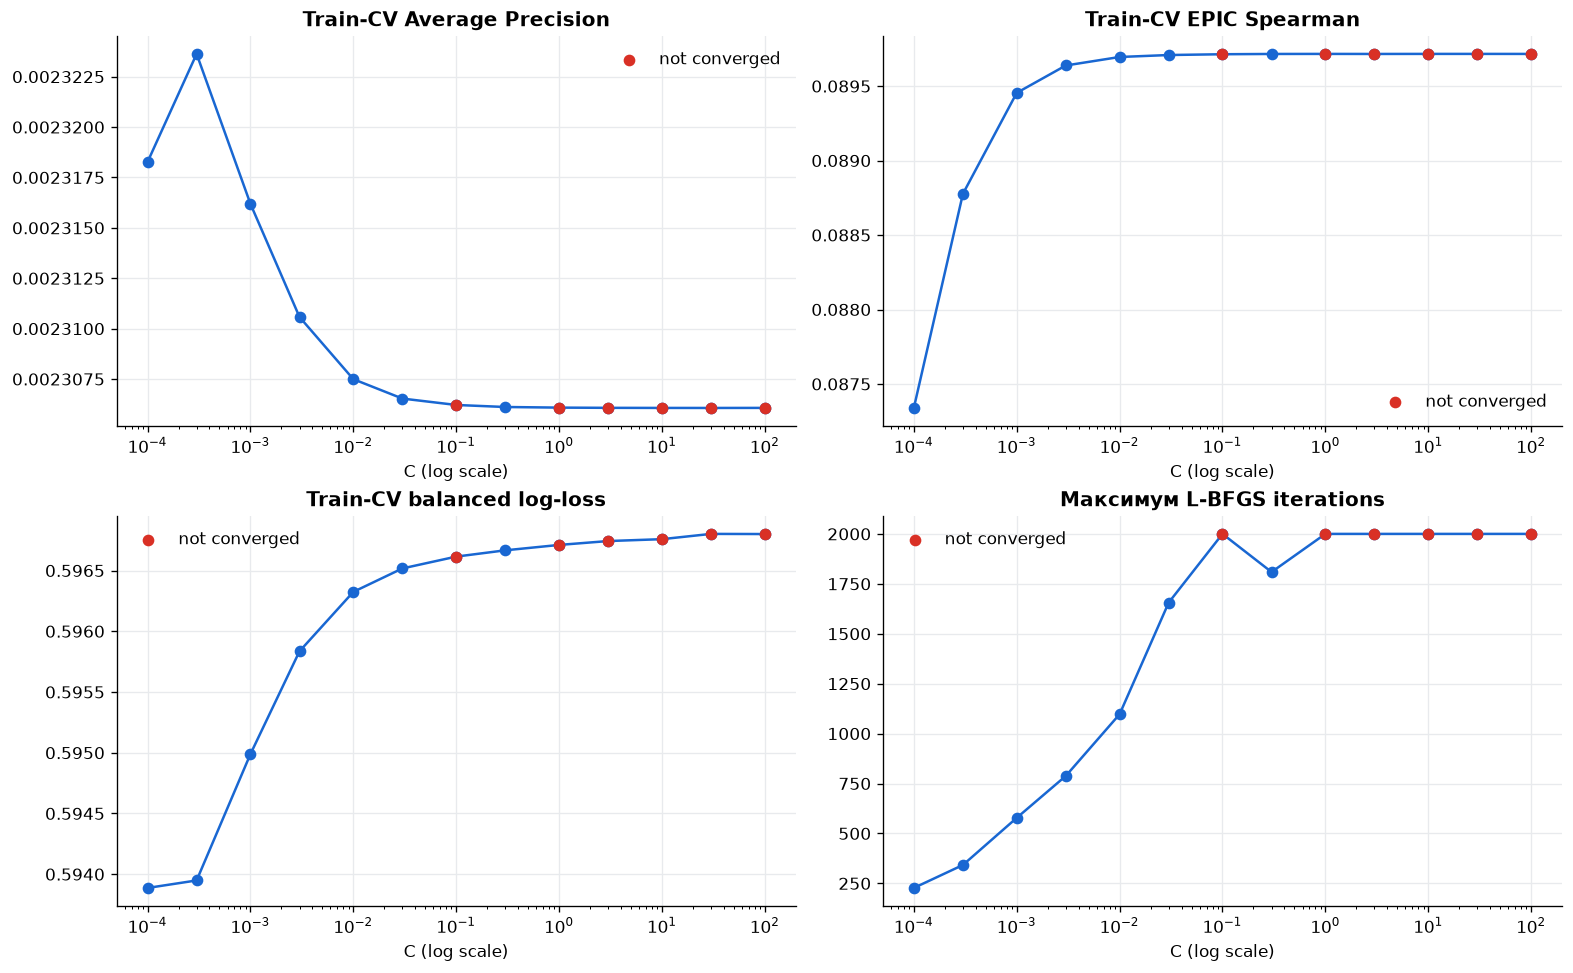

In [13]:
fig_cv, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
panels = [
    ("mean_average_precision", "Train-CV Average Precision", axes[0, 0]),
    ("mean_epic_spearman", "Train-CV EPIC Spearman", axes[0, 1]),
    ("mean_balanced_log_loss", "Train-CV balanced log-loss", axes[1, 0]),
    ("max_iterations", "Максимум L-BFGS iterations", axes[1, 1]),
]
for column, title, ax in panels:
    ax.plot(cv_summary["C"], cv_summary[column], marker="o", color="#1967D2")
    failed = ~cv_summary["all_folds_converged"].astype(bool)
    ax.scatter(
        cv_summary.loc[failed, "C"],
        cv_summary.loc[failed, column],
        color="#D93025",
        label="not converged",
        zorder=3,
    )
    ax.set_xscale("log")
    ax.set_xlabel("C (log scale)")
    ax.set_title(title)
    ax.grid(color="#E8EAED")
    if failed.any():
        ax.legend(frameon=False)
plt.show()


In [14]:
selected = select_regularization(
    cv_summary,
    relative_ap_tolerance=CONFIG.near_best_relative_ap,
)
SELECTED_C = float(selected["C"])
display(selected.to_frame("selected_value"))
print(f"Frozen candidate C before validation: {SELECTED_C:g}")


,selected_value
C,0.0003
mean_average_precision,0.002324
std_average_precision,0.000223
mean_epic_spearman,0.088777
std_epic_spearman,0.002712
mean_balanced_log_loss,0.593948
all_folds_converged,True
max_iterations,342
total_fit_seconds,19.157


Frozen candidate C before validation: 0.0003


,fold,validation_contigs,candidate_average_precision,candidate_epic_spearman,candidate_converged,exp005_average_precision,exp005_epic_spearman,ap_delta,relative_ap_delta,spearman_delta
0,0,"NC_064035.1,NC_064043.1,NC_064048.1",0.002579426,0.090699,True,0.001950485,0.077606,+0.000628941,+32.25%,+0.013093
1,1,"NC_064036.1,NC_064038.1,NC_064045.1",0.002167184,0.085675,True,0.001675085,0.083858,+0.000492100,+29.38%,+0.001817
2,2,"NC_064039.1,NC_064040.1,NC_064047.1",0.002224279,0.089957,True,0.001694223,0.082035,+0.000530056,+31.29%,+0.007922


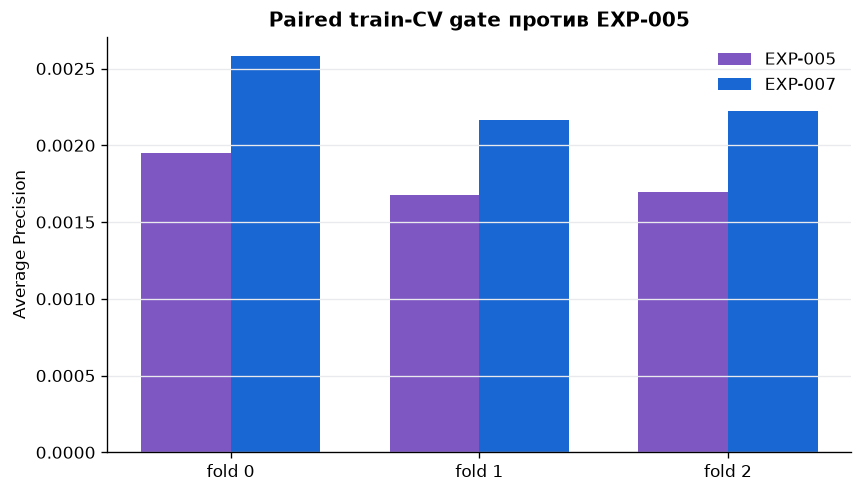

CV gate passed: True


In [15]:
EXP005_DIR = PROJECT_ROOT / "artifacts/experiments/EXP-005/run_001"
exp005_metadata = json.loads((EXP005_DIR / "metadata.json").read_text(encoding="utf-8"))
exp005_cv_results = pd.read_csv(EXP005_DIR / "cv_results.csv")
EXP005_SELECTED_C = float(exp005_metadata["parameters"]["selected_C"])

candidate_cv_selected = cv_results.loc[
    np.isclose(cv_results["C"], SELECTED_C),
    ["fold", "validation_contigs", "average_precision", "epic_spearman", "converged"],
].rename(columns={
    "average_precision": "candidate_average_precision",
    "epic_spearman": "candidate_epic_spearman",
    "converged": "candidate_converged",
})
exp005_cv_selected = exp005_cv_results.loc[
    np.isclose(exp005_cv_results["C"], EXP005_SELECTED_C),
    ["fold", "average_precision", "epic_spearman"],
].rename(columns={
    "average_precision": "exp005_average_precision",
    "epic_spearman": "exp005_epic_spearman",
})
paired_cv_gate = candidate_cv_selected.merge(
    exp005_cv_selected,
    on="fold",
    validate="one_to_one",
)
paired_cv_gate["ap_delta"] = (
    paired_cv_gate["candidate_average_precision"]
    - paired_cv_gate["exp005_average_precision"]
)
paired_cv_gate["relative_ap_delta"] = (
    paired_cv_gate["candidate_average_precision"]
    / paired_cv_gate["exp005_average_precision"] - 1
)
paired_cv_gate["spearman_delta"] = (
    paired_cv_gate["candidate_epic_spearman"]
    - paired_cv_gate["exp005_epic_spearman"]
)
display(paired_cv_gate.style.format({
    "candidate_average_precision": "{:.9f}",
    "exp005_average_precision": "{:.9f}",
    "ap_delta": "{:+.9f}",
    "relative_ap_delta": "{:+.2%}",
    "candidate_epic_spearman": "{:.6f}",
    "exp005_epic_spearman": "{:.6f}",
    "spearman_delta": "{:+.6f}",
}))
CV_GATE_PASSED = bool(
    paired_cv_gate["candidate_converged"].all()
    and (paired_cv_gate["ap_delta"] > 0).all()
)

fig_paired_cv, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(paired_cv_gate))
width = 0.36
ax.bar(x - width/2, paired_cv_gate["exp005_average_precision"], width,
       label="EXP-005", color="#7E57C2")
ax.bar(x + width/2, paired_cv_gate["candidate_average_precision"], width,
       label="EXP-007", color="#1967D2")
ax.set_xticks(x, [f"fold {value}" for value in paired_cv_gate["fold"]])
ax.set_ylabel("Average Precision")
ax.set_title("Paired train-CV gate против EXP-005")
ax.legend(frameon=False)
ax.grid(axis="y", color="#E8EAED")
plt.show()
print("CV gate passed:", CV_GATE_PASSED)


,fold,bin_code,gc_bin,coefficient,odds_multiplier_vs_reference
0,0,0,<0.30,-1.909571,0.148144
1,0,1,"[0.30,0.35)",-0.945612,0.388442
2,0,2,"[0.35,0.40)",0.000000,1.000000
3,0,3,"[0.40,0.45)",0.624645,1.867583
4,0,4,"[0.45,0.50)",0.796924,2.218706
5,0,5,"[0.50,0.55)",0.515519,1.674507
6,0,6,"[0.55,0.60)",-0.042786,0.958117
7,0,7,>=0.60,0.169811,1.185081
8,0,8,missing,0.000000,1.000000
9,1,0,<0.30,-1.816743,0.162554


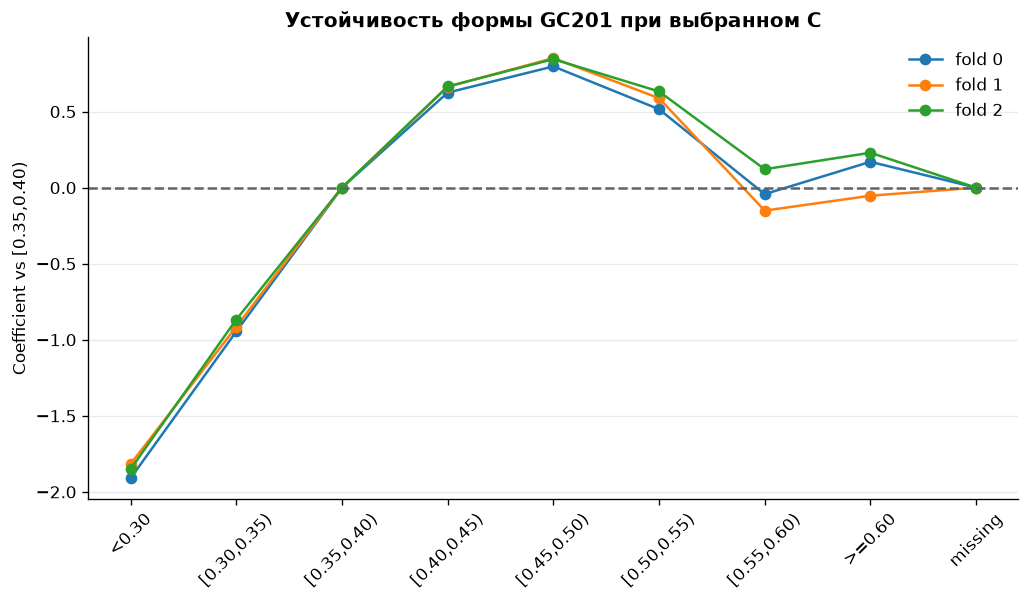

In [16]:
selected_cv_bin_coefs = selected_cv_bin_coefficients(cv_results, C=SELECTED_C)
display(selected_cv_bin_coefs)

fig_cv_bins, ax = plt.subplots(figsize=(10, 5))
for fold, frame in selected_cv_bin_coefs.groupby("fold"):
    ax.plot(frame["gc_bin"], frame["coefficient"], marker="o", label=f"fold {fold}")
ax.axhline(0, color="#5F6368", linestyle="--")
ax.set_ylabel("Coefficient vs [0.35,0.40)")
ax.set_title("Устойчивость формы GC201 при выбранном C")
ax.tick_params(axis="x", rotation=45)
ax.legend(frameon=False)
ax.grid(axis="y", color="#E8EAED")
plt.show()


# STOP 2 — paired CV gate

Проверьте таблицу AP по folds и кривые коэффициентов. По
preregistered правилу validation остаётся закрыт, если хотя бы один
fold не обошёл EXP-005.


In [17]:
assert CV_GATE_PASSED, (
    "EXP-007 не обошёл EXP-005 по AP на каждом train-CV fold. "
    "Не обучаем final candidate и не открываем validation."
)


In [18]:
print(f"Starting full-train fit with C={SELECTED_C:g} ...", flush=True)
started = time.monotonic()
final_fit = fit_binned_gc_logistic(
    train_gc_counts,
    C=SELECTED_C,
    config=CONFIG,
    design=design,
)
full_fit_seconds = time.monotonic() - started
display(final_fit.fit_report)
assert bool(final_fit.fit_report.iloc[0]["converged"]), (
    "Final candidate did not converge; do not open validation."
)
print(f"Full-train candidate fit in {full_fit_seconds:.2f} s")


Starting full-train fit with C=0.0003 ...


C:\ML_Progs\Runtimes\Miniforge3\envs\epic-eda\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


,C,solver,penalty,tol,iterations,max_iter,converged,fit_seconds,aggregate_rows,features,represented_positions,represented_positives,reference_gc_bin,intercept,warnings
0,0.0003,lbfgs,l2,1.000000e-08,406,2000,True,8.219,534159,4379,228064160,170443,"[0.35,0.40)",-0.528803,


Full-train candidate fit in 8.94 s


In [19]:
final_bin_coefficients = final_fit.coefficient_table.loc[
    final_fit.coefficient_table["feature_group"] == "GC201 bin",
    ["category_code", "category", "coefficient"],
].copy()
reference_row = pd.DataFrame([{
    "category_code": CONFIG.reference_bin,
    "category": GC_BIN_LABELS[CONFIG.reference_bin],
    "coefficient": 0.0,
}])
final_bin_coefficients = pd.concat(
    [final_bin_coefficients, reference_row], ignore_index=True
).sort_values("category_code")
final_bin_coefficients["odds_multiplier_vs_reference"] = np.exp(
    final_bin_coefficients["coefficient"]
)
display(final_bin_coefficients)


,category_code,category,coefficient,odds_multiplier_vs_reference
0,0,<0.30,-1.861994,0.155363
1,1,"[0.30,0.35)",-0.907784,0.403417
8,2,"[0.35,0.40)",0.000000,1.000000
2,3,"[0.40,0.45)",0.649993,1.915527
3,4,"[0.45,0.50)",0.828962,2.290940
4,5,"[0.50,0.55)",0.577389,1.781382
5,6,"[0.55,0.60)",-0.020874,0.979343
6,7,>=0.60,0.116917,1.124026
7,8,missing,0.000000,1.000000


# STOP 3 — только теперь открывается validation

Границы bins, reference, folds, `C` и final fit уже зафиксированы.
После следующей ячейки менять их нельзя; изменение потребует нового
experiment ID.


In [20]:
started = time.monotonic()
validation_gc_counts = split_kmer_gc_counts(
    split,
    sequences,
    "validation",
    config=CONFIG,
)
validation_count_seconds = time.monotonic() - started
validation_gc_diagnostics = gc_count_diagnostics(validation_gc_counts)
validation_kmer_counts = kmer_counts_from_gc_counts(
    validation_gc_counts,
    ks=CONFIG.ks,
)
display(validation_gc_diagnostics)
print(f"Full validation counted in {validation_count_seconds:.2f} s")


,split,aggregate_rows,positions,positives,unique_gc_fractions,zero_valid_positions,zero_valid_fraction,totals_memory_mib,positives_memory_mib
0,validation,2054867,83807486,56205,4950,0,0.0,246.919035,8.040316


Full validation counted in 11.72 s


In [21]:
candidate_evaluation = evaluate_binned_gc_logistic(
    validation_gc_counts,
    final_fit,
    config=CONFIG,
    variant="EXP-007 LR + fixed GC201 bins",
)
candidate_row = candidate_evaluation.metric_summary.iloc[0]
display(candidate_evaluation.metric_summary)
display(candidate_evaluation.per_contig_metrics)


,segment,variant,average_precision,epic_spearman,population_log_loss,balanced_log_loss,positions,positives,prevalence
0,overall,EXP-007 LR + fixed GC201 bins,0.002054,0.104302,0.597014,0.595497,83807486,56205,0.000671


,contig,variant,average_precision,epic_spearman,population_log_loss,balanced_log_loss,positions,positives,prevalence
0,NC_064034.1,EXP-007 LR + fixed GC201 bins,0.002241,0.123295,0.596412,0.589862,33949114,23529,0.000693
1,NC_064041.1,EXP-007 LR + fixed GC201 bins,0.001710,0.127176,0.595137,0.599181,24146754,13984,0.000579
2,NC_064042.1,EXP-007 LR + fixed GC201 bins,0.002137,0.123564,0.599573,0.600034,25711618,18692,0.000727


In [22]:
lookup_fit = fit_kmer_lookup(train_kmer_counts, LOOKUP_CONFIG)
lookup_evaluation = evaluate_kmer_lookup(validation_kmer_counts, lookup_fit)
exp003_row = lookup_evaluation.metric_summary.loc[
    lookup_evaluation.metric_summary["k"] == 6
].iloc[0]
display(exp003_row.to_frame("EXP-003"))


,EXP-003
segment,overall
segment_value,overall
k,6
variant,6mer_lookup
average_precision,0.001601
epic_spearman,0.097186
positions,83807486
positives,56205
prevalence,0.000671
unique_score_levels,4097


In [23]:
EXP006_DIR = PROJECT_ROOT / "artifacts/experiments/EXP-006/run_001"
exp006_metadata = json.loads((EXP006_DIR / "metadata.json").read_text(encoding="utf-8"))
exp006_per_contig = pd.read_csv(EXP006_DIR / "per_contig_metrics.csv")
exp006_pr_all = pd.read_csv(EXP006_DIR / "precision_recall.csv")
exp006_pr = exp006_pr_all.loc[
    exp006_pr_all["variant"] == "EXP-006 LR + GC201"
].copy()
exp006_ap = float(exp006_metadata["metrics"]["candidate_average_precision"])
exp006_spearman = float(exp006_metadata["metrics"]["candidate_epic_spearman"])

exp005_per_contig = pd.read_csv(EXP005_DIR / "per_contig_metrics.csv")
exp005_pr = pd.read_csv(EXP005_DIR / "precision_recall.csv")
exp005_ap = float(exp005_metadata["metrics"]["candidate_average_precision"])
exp005_spearman = float(exp005_metadata["metrics"]["candidate_epic_spearman"])
display(pd.DataFrame([
    {"variant": "EXP-005", "AP": exp005_ap, "Spearman": exp005_spearman},
    {"variant": "EXP-006", "AP": exp006_ap, "Spearman": exp006_spearman},
]))


,variant,AP,Spearman
0,EXP-005,0.001606,0.097569
1,EXP-006,0.001574,0.101205


In [24]:
metric_summary = pd.DataFrame([
    {
        "variant": "EXP-003 6-mer lookup",
        "average_precision": float(exp003_row["average_precision"]),
        "epic_spearman": float(exp003_row["epic_spearman"]),
    },
    {
        "variant": "EXP-005 hierarchical LR",
        "average_precision": exp005_ap,
        "epic_spearman": exp005_spearman,
    },
    {
        "variant": "EXP-006 linear GC201",
        "average_precision": exp006_ap,
        "epic_spearman": exp006_spearman,
    },
    {
        "variant": "EXP-007 binned GC201",
        "average_precision": float(candidate_row["average_precision"]),
        "epic_spearman": float(candidate_row["epic_spearman"]),
    },
])
display(metric_summary)

exp003_contigs = lookup_evaluation.per_contig_metrics.loc[
    lookup_evaluation.per_contig_metrics["k"] == 6,
    ["segment_value", "average_precision", "epic_spearman"],
].rename(columns={
    "segment_value": "contig",
    "average_precision": "exp003_average_precision",
    "epic_spearman": "exp003_epic_spearman",
})
exp005_contigs = exp005_per_contig.rename(columns={
    "candidate_average_precision": "exp005_average_precision",
    "candidate_epic_spearman": "exp005_epic_spearman",
})[["contig", "exp005_average_precision", "exp005_epic_spearman"]]
exp006_contigs = exp006_per_contig.rename(columns={
    "candidate_average_precision": "exp006_average_precision",
    "candidate_epic_spearman": "exp006_epic_spearman",
})[["contig", "exp006_average_precision", "exp006_epic_spearman"]]
candidate_contigs = candidate_evaluation.per_contig_metrics.rename(columns={
    "average_precision": "candidate_average_precision",
    "epic_spearman": "candidate_epic_spearman",
})[["contig", "candidate_average_precision", "candidate_epic_spearman"]]
per_contig_metrics = (
    exp003_contigs
    .merge(exp005_contigs, on="contig", validate="one_to_one")
    .merge(exp006_contigs, on="contig", validate="one_to_one")
    .merge(candidate_contigs, on="contig", validate="one_to_one")
)
display(per_contig_metrics)


,variant,average_precision,epic_spearman
0,EXP-003 6-mer lookup,0.001601,0.097186
1,EXP-005 hierarchical LR,0.001606,0.097569
2,EXP-006 linear GC201,0.001574,0.101205
3,EXP-007 binned GC201,0.002054,0.104302


,contig,exp003_average_precision,exp003_epic_spearman,exp005_average_precision,exp005_epic_spearman,exp006_average_precision,exp006_epic_spearman,candidate_average_precision,candidate_epic_spearman
0,NC_064034.1,0.001717,0.109397,0.001725,0.109559,0.001687,0.114905,0.002241,0.123295
1,NC_064041.1,0.001381,0.120721,0.001386,0.121407,0.001340,0.123050,0.001710,0.127176
2,NC_064042.1,0.001655,0.115426,0.001658,0.116599,0.001640,0.115082,0.002137,0.123564


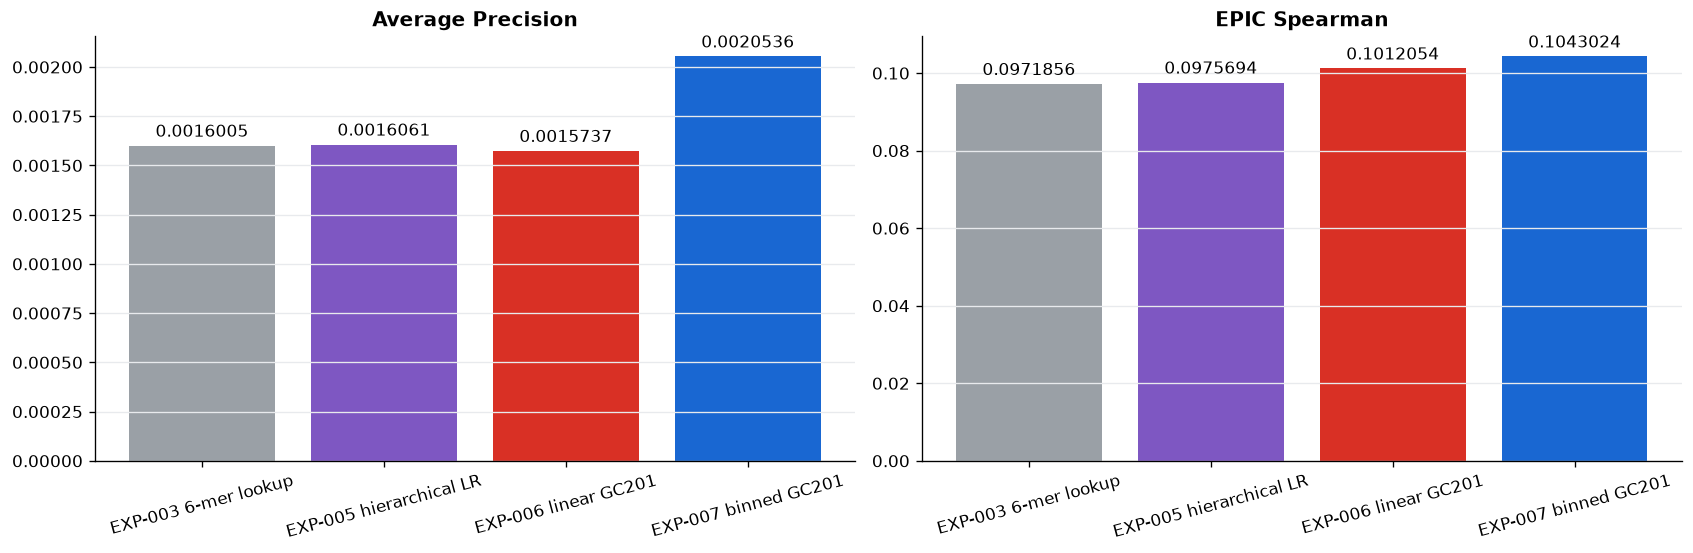

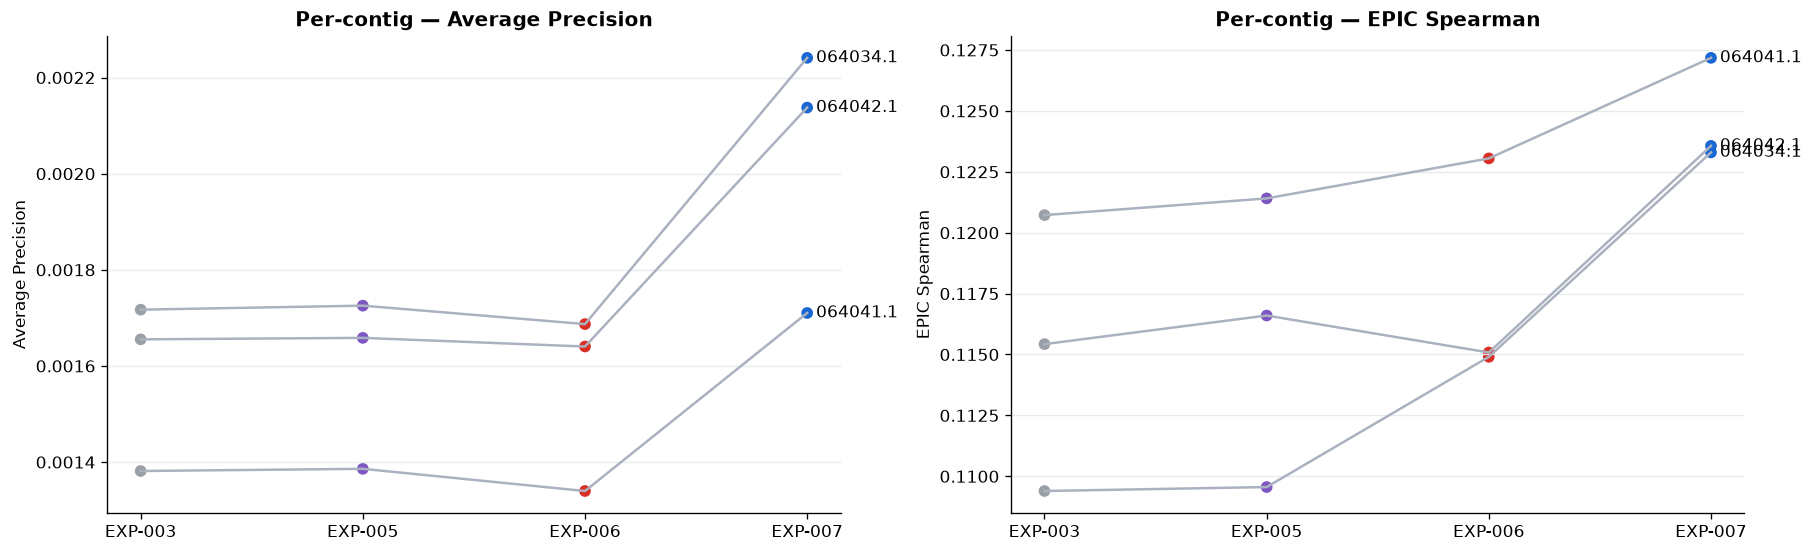

In [25]:
colors = ["#9AA0A6", "#7E57C2", "#D93025", "#1967D2"]
fig_metrics, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
for ax, metric, title in [
    (axes[0], "average_precision", "Average Precision"),
    (axes[1], "epic_spearman", "EPIC Spearman"),
]:
    bars = ax.bar(metric_summary["variant"], metric_summary[metric], color=colors)
    ax.bar_label(bars, fmt="%.7f", padding=3)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=15)
    ax.grid(axis="y", color="#E8EAED")
plt.show()

fig_contigs, axes = plt.subplots(1, 2, figsize=(15, 4.5), constrained_layout=True)
for ax, metric, label in [
    (axes[0], "average_precision", "Average Precision"),
    (axes[1], "epic_spearman", "EPIC Spearman"),
]:
    columns = [
        f"exp003_{metric}", f"exp005_{metric}",
        f"exp006_{metric}", f"candidate_{metric}",
    ]
    for _, row in per_contig_metrics.iterrows():
        values = [row[column] for column in columns]
        ax.plot(range(4), values, color="#AAB2C0")
        ax.scatter(range(4), values, color=colors)
        ax.text(3.04, values[-1], row["contig"].replace("NC_", ""), va="center")
    ax.set_xticks(range(4), ["EXP-003", "EXP-005", "EXP-006", "EXP-007"])
    ax.set_ylabel(label)
    ax.set_title(f"Per-contig — {label}")
    ax.grid(axis="y", color="#E8EAED")
plt.show()


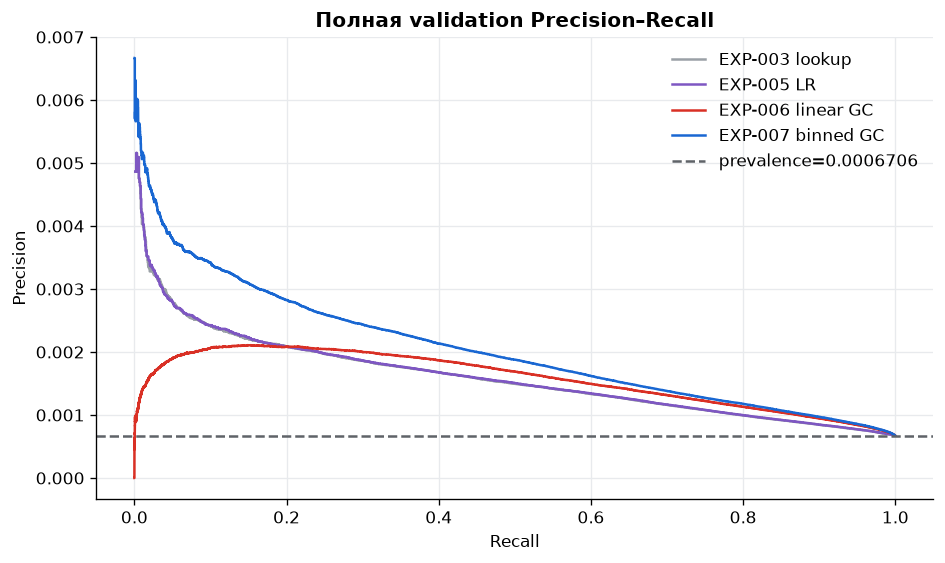

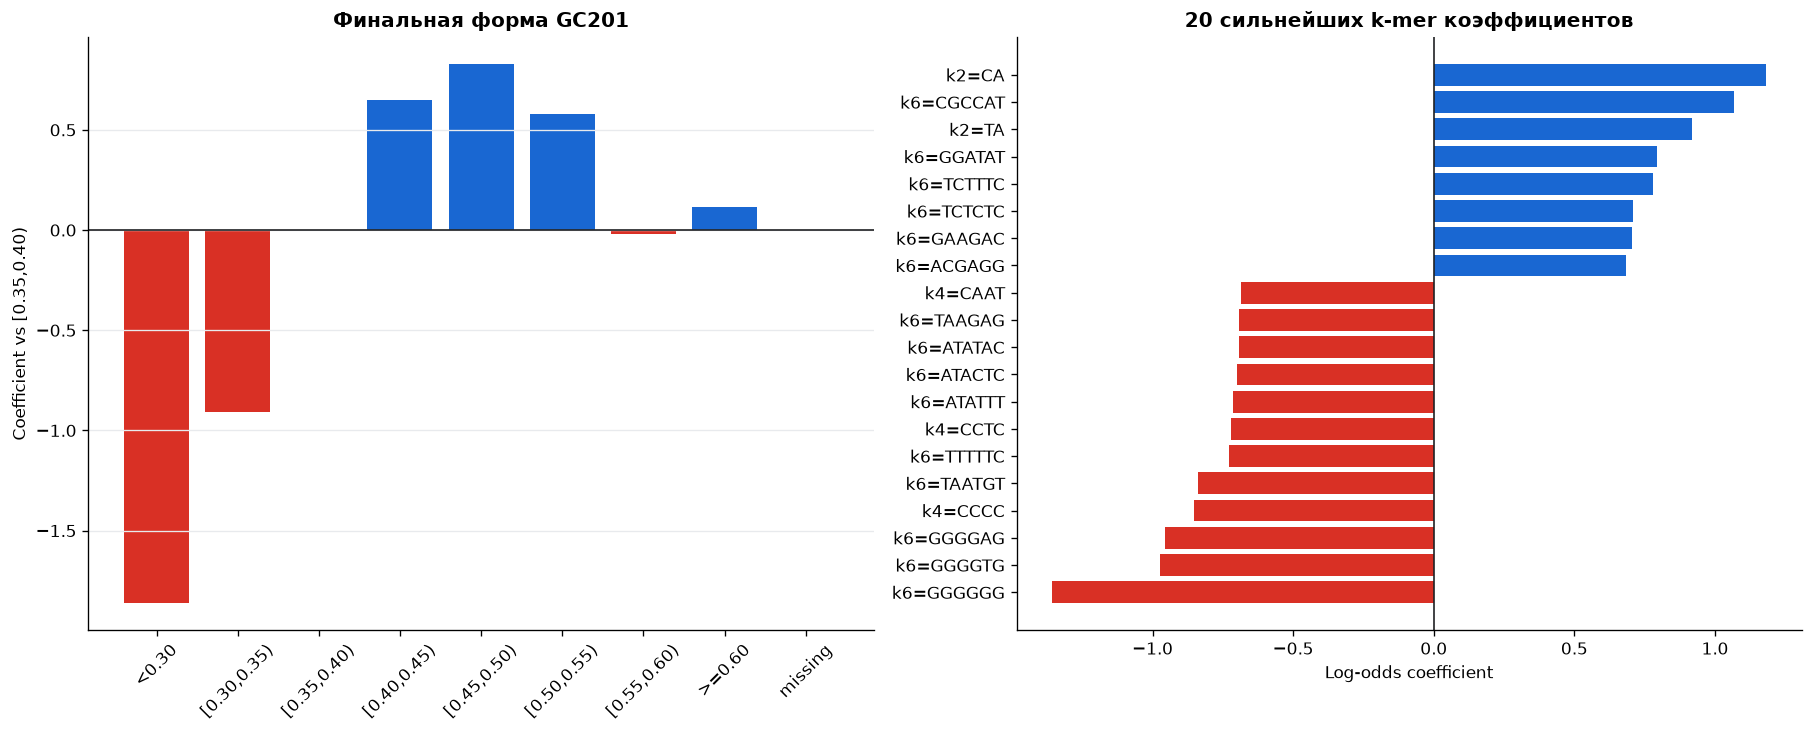

In [26]:
reference_pr = lookup_evaluation.precision_recall.loc[
    lookup_evaluation.precision_recall["k"] == 6
]
candidate_pr = candidate_evaluation.precision_recall
fig_pr, ax = plt.subplots(figsize=(9, 5))
ax.step(reference_pr["recall"], reference_pr["precision"], where="post",
        color="#9AA0A6", label="EXP-003 lookup")
ax.step(exp005_pr["recall"], exp005_pr["precision"], where="post",
        color="#7E57C2", label="EXP-005 LR")
ax.step(exp006_pr["recall"], exp006_pr["precision"], where="post",
        color="#D93025", label="EXP-006 linear GC")
ax.step(candidate_pr["recall"], candidate_pr["precision"], where="post",
        color="#1967D2", label="EXP-007 binned GC")
ax.axhline(candidate_row["prevalence"], color="#5F6368", linestyle="--",
           label=f"prevalence={candidate_row['prevalence']:.7f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Полная validation Precision–Recall")
ax.legend(frameon=False)
ax.grid(color="#E8EAED")
plt.show()

strongest = (
    final_fit.coefficient_table.loc[
        final_fit.coefficient_table["feature_group"] != "GC201 bin"
    ]
    .nlargest(20, "absolute_coefficient")
    .sort_values("coefficient")
)
fig_coefficients, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)
axes[0].bar(
    final_bin_coefficients["category"],
    final_bin_coefficients["coefficient"],
    color=np.where(final_bin_coefficients["coefficient"] >= 0, "#1967D2", "#D93025"),
)
axes[0].axhline(0, color="#202124", linewidth=1)
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_ylabel("Coefficient vs [0.35,0.40)")
axes[0].set_title("Финальная форма GC201")
axes[0].grid(axis="y", color="#E8EAED")
axes[1].barh(
    strongest["feature_name"],
    strongest["coefficient"],
    color=np.where(strongest["coefficient"] >= 0, "#1967D2", "#D93025"),
)
axes[1].axvline(0, color="#202124", linewidth=1)
axes[1].set_xlabel("Log-odds coefficient")
axes[1].set_title("20 сильнейших k-mer коэффициентов")
plt.show()


## 7. Формальное решение

EXP-005 — feature-ablation reference. EXP-003 — действующий
champion. EXP-006 показывается для проверки, исправили ли bins
проблему линейного GC.


In [27]:
candidate_ap = float(candidate_row["average_precision"])
candidate_spearman = float(candidate_row["epic_spearman"])
exp003_ap = float(exp003_row["average_precision"])
exp003_spearman = float(exp003_row["epic_spearman"])

feature_ap_wins = int((
    per_contig_metrics["candidate_average_precision"]
    > per_contig_metrics["exp005_average_precision"]
).sum())
champion_ap_wins = int((
    per_contig_metrics["candidate_average_precision"]
    > per_contig_metrics["exp003_average_precision"]
).sum())
feature_checks = pd.Series({
    "AP > EXP-005": candidate_ap > exp005_ap,
    "Spearman >= EXP-005": candidate_spearman >= exp005_spearman,
    "AP wins vs EXP-005 on at least 2/3 contigs": feature_ap_wins >= 2,
}, name="passed")
champion_checks = pd.Series({
    "relative AP gain vs EXP-003 >= 1%": candidate_ap / exp003_ap - 1 >= 0.01,
    "Spearman >= EXP-003": candidate_spearman >= exp003_spearman,
    "AP wins vs EXP-003 on at least 2/3 contigs": champion_ap_wins >= 2,
}, name="passed")
display(Markdown("### Feature ablation vs EXP-005"))
display(feature_checks.to_frame())
display(Markdown("### Champion gate vs EXP-003"))
display(champion_checks.to_frame())

if bool(champion_checks.all()):
    DECISION = "adopt"
elif bool(feature_checks.all()):
    DECISION = "iterate"
else:
    DECISION = "reject"
INTERPRETATION = (
    f"Fixed GC201 bins changed AP vs EXP-005 from {exp005_ap:.9f} "
    f"to {candidate_ap:.9f} ({candidate_ap / exp005_ap - 1:+.2%}) "
    f"and Spearman from {exp005_spearman:.6f} to {candidate_spearman:.6f}; "
    f"vs linear EXP-006 AP change is {candidate_ap / exp006_ap - 1:+.2%}; "
    f"vs EXP-003 AP change is {candidate_ap / exp003_ap - 1:+.2%}. "
    f"Decision: {DECISION}."
)
display(Markdown(f"**Decision: `{DECISION}`.** {INTERPRETATION}"))


### Feature ablation vs EXP-005

,passed
AP > EXP-005,True
Spearman >= EXP-005,True
AP wins vs EXP-005 on at least 2/3 contigs,True


### Champion gate vs EXP-003

,passed
relative AP gain vs EXP-003 >= 1%,True
Spearman >= EXP-003,True
AP wins vs EXP-003 on at least 2/3 contigs,True


**Decision: `adopt`.** Fixed GC201 bins changed AP vs EXP-005 from 0.001606098 to 0.002053635 (+27.86%) and Spearman from 0.097569 to 0.104302; vs linear EXP-006 AP change is +30.49%; vs EXP-003 AP change is +28.31%. Decision: adopt.

## 8. Сохранение

Только эта ячейка создаёт immutable run `EXP-007/run_001`.


In [28]:
PLOT_DIR.mkdir(parents=True, exist_ok=True)
plot_objects = {
    "01_train_bin_enrichment.png": fig_train_bins,
    "02_train_cv_diagnostics.png": fig_cv,
    "03_paired_cv_gate.png": fig_paired_cv,
    "04_cv_bin_coefficients.png": fig_cv_bins,
    "05_validation_metrics.png": fig_metrics,
    "06_per_contig_metrics.png": fig_contigs,
    "07_precision_recall.png": fig_pr,
    "08_final_coefficients.png": fig_coefficients,
}
for filename, figure in plot_objects.items():
    figure.savefig(PLOT_DIR / filename, dpi=170, bbox_inches="tight", facecolor="white")

criteria_table = pd.concat([
    feature_checks.rename("passed").to_frame().assign(comparison="EXP-005"),
    champion_checks.rename("passed").to_frame().assign(comparison="EXP-003"),
]).rename_axis("criterion").reset_index()
precision_recall = pd.concat([
    reference_pr.assign(variant="EXP-003 6-mer lookup"),
    exp005_pr.assign(variant="EXP-005 hierarchical LR"),
    exp006_pr.assign(variant="EXP-006 linear GC201"),
    candidate_pr.assign(variant="EXP-007 binned GC201"),
], ignore_index=True)
tables = {
    "train_gc_diagnostics.csv": train_gc_diagnostics,
    "validation_gc_diagnostics.csv": validation_gc_diagnostics,
    "train_bin_enrichment.csv": train_bin_enrichment,
    "fold_bin_enrichment.csv": fold_bin_enrichment,
    "cv_fold_assignment.csv": fold_assignment,
    "cv_results.csv": cv_results,
    "cv_summary.csv": cv_summary,
    "paired_cv_gate.csv": paired_cv_gate,
    "selected_cv_bin_coefficients.csv": selected_cv_bin_coefs,
    "metric_summary.csv": metric_summary,
    "per_contig_metrics.csv": per_contig_metrics,
    "criteria.csv": criteria_table,
    "fit_report.csv": final_fit.fit_report,
    "coefficient_table.csv": final_fit.coefficient_table,
    "final_bin_coefficients.csv": final_bin_coefficients,
    "precision_recall.csv": precision_recall,
}
for filename, table in tables.items():
    table.to_csv(ARTIFACT_DIR / filename, index=False)
candidate_evaluation.positive_predictions.to_csv(
    ARTIFACT_DIR / "positive_predictions.csv.gz",
    index=False,
    compression="gzip",
)

METRICS = {
    "reference_average_precision": exp003_ap,
    "candidate_average_precision": candidate_ap,
    "delta_average_precision": candidate_ap - exp003_ap,
    "reference_epic_spearman": exp003_spearman,
    "candidate_epic_spearman": candidate_spearman,
    "delta_epic_spearman": candidate_spearman - exp003_spearman,
    "ablation_reference_average_precision": exp005_ap,
    "ablation_delta_average_precision": candidate_ap - exp005_ap,
    "ablation_reference_epic_spearman": exp005_spearman,
    "ablation_delta_epic_spearman": candidate_spearman - exp005_spearman,
    "linear_gc_average_precision": exp006_ap,
    "linear_gc_epic_spearman": exp006_spearman,
}
PARAMETERS = CONFIG.to_dict() | {
    "selected_C": SELECTED_C,
    "reference_experiment": "EXP-003/run_001",
    "ablation_reference": "EXP-005/run_001",
    "diagnostic_reference": "EXP-006/run_001",
    "cv_gate": "AP > EXP-005 on every identical train-CV fold",
    "cv_gate_passed": CV_GATE_PASSED,
    "validation_population": "all whitelist positions",
    "validation_used_for_C_selection": False,
    "score": "raw float64 logistic decision_function",
}
record = build_run_record(
    SPEC,
    split,
    run_name=RUN_NAME,
    notebook_path=NOTEBOOK_PATH,
    parameters=PARAMETERS,
    metrics=METRICS,
    interpretation=INTERPRETATION,
    decision=DECISION,
)
output = save_run_record(PROJECT_ROOT, record)
(output / "config.json").write_text(
    json.dumps(PARAMETERS, ensure_ascii=False, indent=2) + "\n",
    encoding="utf-8",
)
print("Saved run:", output)


Saved run: D:\Projects\EPIC\EPIC\artifacts\experiments\EXP-007\run_001


## 9. Синхронизация отчёта

Финальная ячейка не обучает модель: она читает сохранённые CSV/JSON
и обновляет только автоматический блок карточки EXP-007.


In [29]:
from ml_project.epic_gc_binned_report import sync_exp007_report

experiment_note = sync_exp007_report(PROJECT_ROOT, run_name=RUN_NAME)
print("Updated experiment note:", experiment_note)


Updated experiment note: D:\Projects\EPIC\EPIC\experiments\EXP-007.md
